In [6]:
import pandas as pd
df = pd.read_csv("heart.csv")
print(df.head())
print(df["target"].value_counts())
x = df.drop("target",axis=1)
y = df["target"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state = 42)

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   49    0   3       177   150    0       95      0      2.3   0       0
1   56    1   0       124   172    1       86      1      0.5   0       1
2   66    0   3       100   239    0      105      0      1.7   0       0
3   64    0   0       168   222    0       95      1      2.8   0       1
4   60    1   2       153   358    0      147      0      3.2   0       1
1    6
0    3
Name: target, dtype: int64


In [7]:
from sklearn.tree import DecisionTreeClassifier
df = DecisionTreeClassifier(random_state=42)
df.fit(x_train,y_train)
pred = df.predict(x_test)
print(pred[:10])

[1 0]


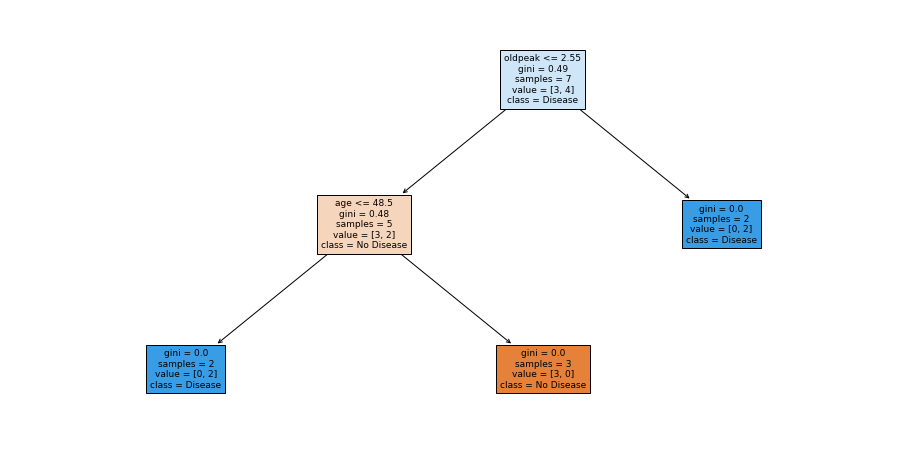

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize = (16,8))
plot_tree(df,feature_names = x.columns,class_names = ["No Disease","Disease"],filled = True,max_depth = 3, fontsize = 9)
plt.show()

In [9]:
for depth in[2, 3, 4, 5, None]:
    dt_d = DecisionTreeClassifier(max_depth = depth,random_state=42)
    dt_d.fit(x_train,y_train)
    train_acc = dt_d.score(x_test,y_test)
    test_acc = dt_d.score(x_test,y_test)
    print(depth,train_acc,test_acc)

2 0.5 0.5
3 0.5 0.5
4 0.5 0.5
5 0.5 0.5
None 0.5 0.5


In [10]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 100,random_state = 42)
rf.fit(x_train,y_train)
pred_rf = rf.predict(x_test)

age         0.181278
oldpeak     0.166791
chol        0.156902
cp          0.137075
thalach     0.124702
trestbps    0.085388
exang       0.062514
sex         0.049433
ca          0.035916
fbs         0.000000
dtype: float64


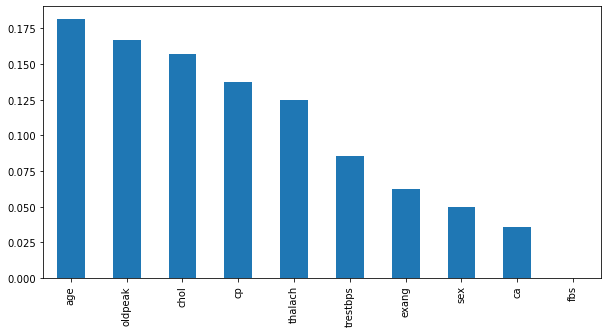

In [11]:
import numpy as np
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index = x.columns).sort_values(ascending = False)
print(feat_imp)
feat_imp.plot(kind="bar",figsize = (10,5))
plt.title=("Feature Importance")
plt.show()

In [12]:
for n in[50,100,200]:
    for depth in[3,5,None]:
        rf_t = RandomForestClassifier(n_estimators = n,max_depth = depth,random_state = 42)
        rf_t.fit(x_train,y_train)
        acc = rf_t.score(x_test,y_test)
        print(n, depth, acc)

50 3 0.5
50 5 0.5
50 None 0.5
100 3 1.0
100 5 1.0
100 None 1.0
200 3 1.0
200 5 1.0
200 None 1.0


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression":LogisticRegression(max_iter = 1000),
    "KNN (k=5)":KNeighborsClassifier(n_neighbors = 5),
    "Decision Tree":DecisionTreeClassifier(random_state = 42),
    "Random Forest":RandomForestClassifier(n_estimators = 100 , random_state = 42),
}
results = []
for name, m in models.items():
    m.fit(x_train, y_train)
    p = m. predict(x_test)
    results.append([
        name,
        accuracy_score(y_test, p),
        precision_score(y_test, p),
        recall_score(y_test, p),
        f1_score(y_test, p)
    ])
    comparison_df = pd.DataFrame(results, columns = ["Models", "Accuracy", "Precision", "Recall", "F1 Score"])
    print(comparison_df)

                Models  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression       0.0        0.0     0.0       0.0
                Models  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression       0.0        0.0     0.0  0.000000
1            KNN (k=5)       0.5        1.0     0.5  0.666667
                Models  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression       0.0        0.0     0.0  0.000000
1            KNN (k=5)       0.5        1.0     0.5  0.666667
2        Decision Tree       0.5        1.0     0.5  0.666667
                Models  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression       0.0        0.0     0.0  0.000000
1            KNN (k=5)       0.5        1.0     0.5  0.666667
2        Decision Tree       0.5        1.0     0.5  0.666667
3        Random Forest       1.0        1.0     1.0  1.000000


C:\Users\ITLAB\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
